In [1]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
import os.path as op
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

## Define the helpers

In [ ]:
def get_best_data(file_list):
    best_mean = -1
    best_data = None

    for f in file_list:
        data = np.load(f, allow_pickle=True).item()
        curr_mean = np.mean(data['accuracy'], axis=0)
        if curr_mean > best_mean:
            best_mean = curr_mean
            best_data = data
    
    return best_data


def get_file_number(file_name):
    match = re.search(r'outputs_(\d+)', file_name)
    return int(match.group(1)) if match else None


def get_bin_with_highest_abs_coeff(coefs):
    """Returns the 0-based bin number with the highest absolute coefficient across all bins and PCs."""
    max_abs = 0
    best_bin = None
    for bin_idx, coeff_array in enumerate(coefs):
        # print(f"coeff array to test: {coeff_array}")
        for coef in coeff_array:
            current_max = np.max(np.abs(coef))
            if current_max > max_abs:
                # print(f"found a greater absolute coefficient: {current_max}")
                max_abs = current_max
                best_bin = bin_idx
    return best_bin  # 0-based


def plot_accuracy_curve(ax, data, filename, method_name, n_splits=10, color=None, linewidth=3, alpha=0.1, meth_in_label=False):
    """Handles the mean, SEM calculation, and plotting for a single file."""

    accuracy = np.array(data['accuracy'], dtype=float)
    sem = np.array(data['variance'], dtype=float) / np.sqrt(float(n_splits))
    n_PCs = get_file_number(filename)
    x_axis = np.arange(len(accuracy))

    upper, lower = accuracy + sem, accuracy - sem
    if method_name == 'rPCA':
        label = f"{n_PCs} rPCs" if meth_in_label else f"{n_PCs}"
    else:
        label = f"{n_PCs} gcPCs" if meth_in_label else f"{n_PCs}"

    # Plot the main line
    line, = ax.plot(x_axis, accuracy,
                    label=label,
                    color=color, linewidth=linewidth)
    
    # Plot the shaded SEM area
    ax.fill_between(x_axis, lower, upper,
                    color=line.get_color(), alpha=alpha)
    
    return line.get_color()


def get_best_file_info(file_list):
    """Returns both the data and the filename of the best performing file - Based on mean accuracy."""

    if not file_list:
        return None, None, None

    best_max = -1
    best_data = None
    best_file = None
    best_n_bins = None

    for file in file_list:
        data = np.load(file, allow_pickle=True).item()
        max_acc = np.max(data['accuracy'])
        max_acc_n_bins = np.argmax(data['accuracy'])
        if max_acc > best_max:
            best_max = max_acc
            best_data = data
            best_file = file 
            best_n_bins = max_acc_n_bins

    return best_data, best_file, best_n_bins

## Plot the logit accuracies for all the models (PCA $\times$ number of bins) across brain regions and PCA and select the best models for each brain regions and PCA. 

40 file(s) to plot: ['./outputs-7\\gcPCA_outputs_10_ctx.npy', './outputs-7\\gcPCA_outputs_10_stn.npy', './outputs-7\\gcPCA_outputs_12_ctx.npy', './outputs-7\\gcPCA_outputs_12_stn.npy', './outputs-7\\gcPCA_outputs_14_ctx.npy', './outputs-7\\gcPCA_outputs_14_stn.npy', './outputs-7\\gcPCA_outputs_16_ctx.npy', './outputs-7\\gcPCA_outputs_16_stn.npy', './outputs-7\\gcPCA_outputs_18_ctx.npy', './outputs-7\\gcPCA_outputs_18_stn.npy', './outputs-7\\gcPCA_outputs_20_ctx.npy', './outputs-7\\gcPCA_outputs_20_stn.npy', './outputs-7\\gcPCA_outputs_2_ctx.npy', './outputs-7\\gcPCA_outputs_2_stn.npy', './outputs-7\\gcPCA_outputs_4_ctx.npy', './outputs-7\\gcPCA_outputs_4_stn.npy', './outputs-7\\gcPCA_outputs_6_ctx.npy', './outputs-7\\gcPCA_outputs_6_stn.npy', './outputs-7\\gcPCA_outputs_8_ctx.npy', './outputs-7\\gcPCA_outputs_8_stn.npy', './outputs-7\\rPCA_outputs_10_ctx.npy', './outputs-7\\rPCA_outputs_10_stn.npy', './outputs-7\\rPCA_outputs_12_ctx.npy', './outputs-7\\rPCA_outputs_12_stn.npy', './outp

C:\Users\Loquet Jeremie\AppData\Local\Temp\ipykernel_18864\3484603786.py:78: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 0.85, 0.97])


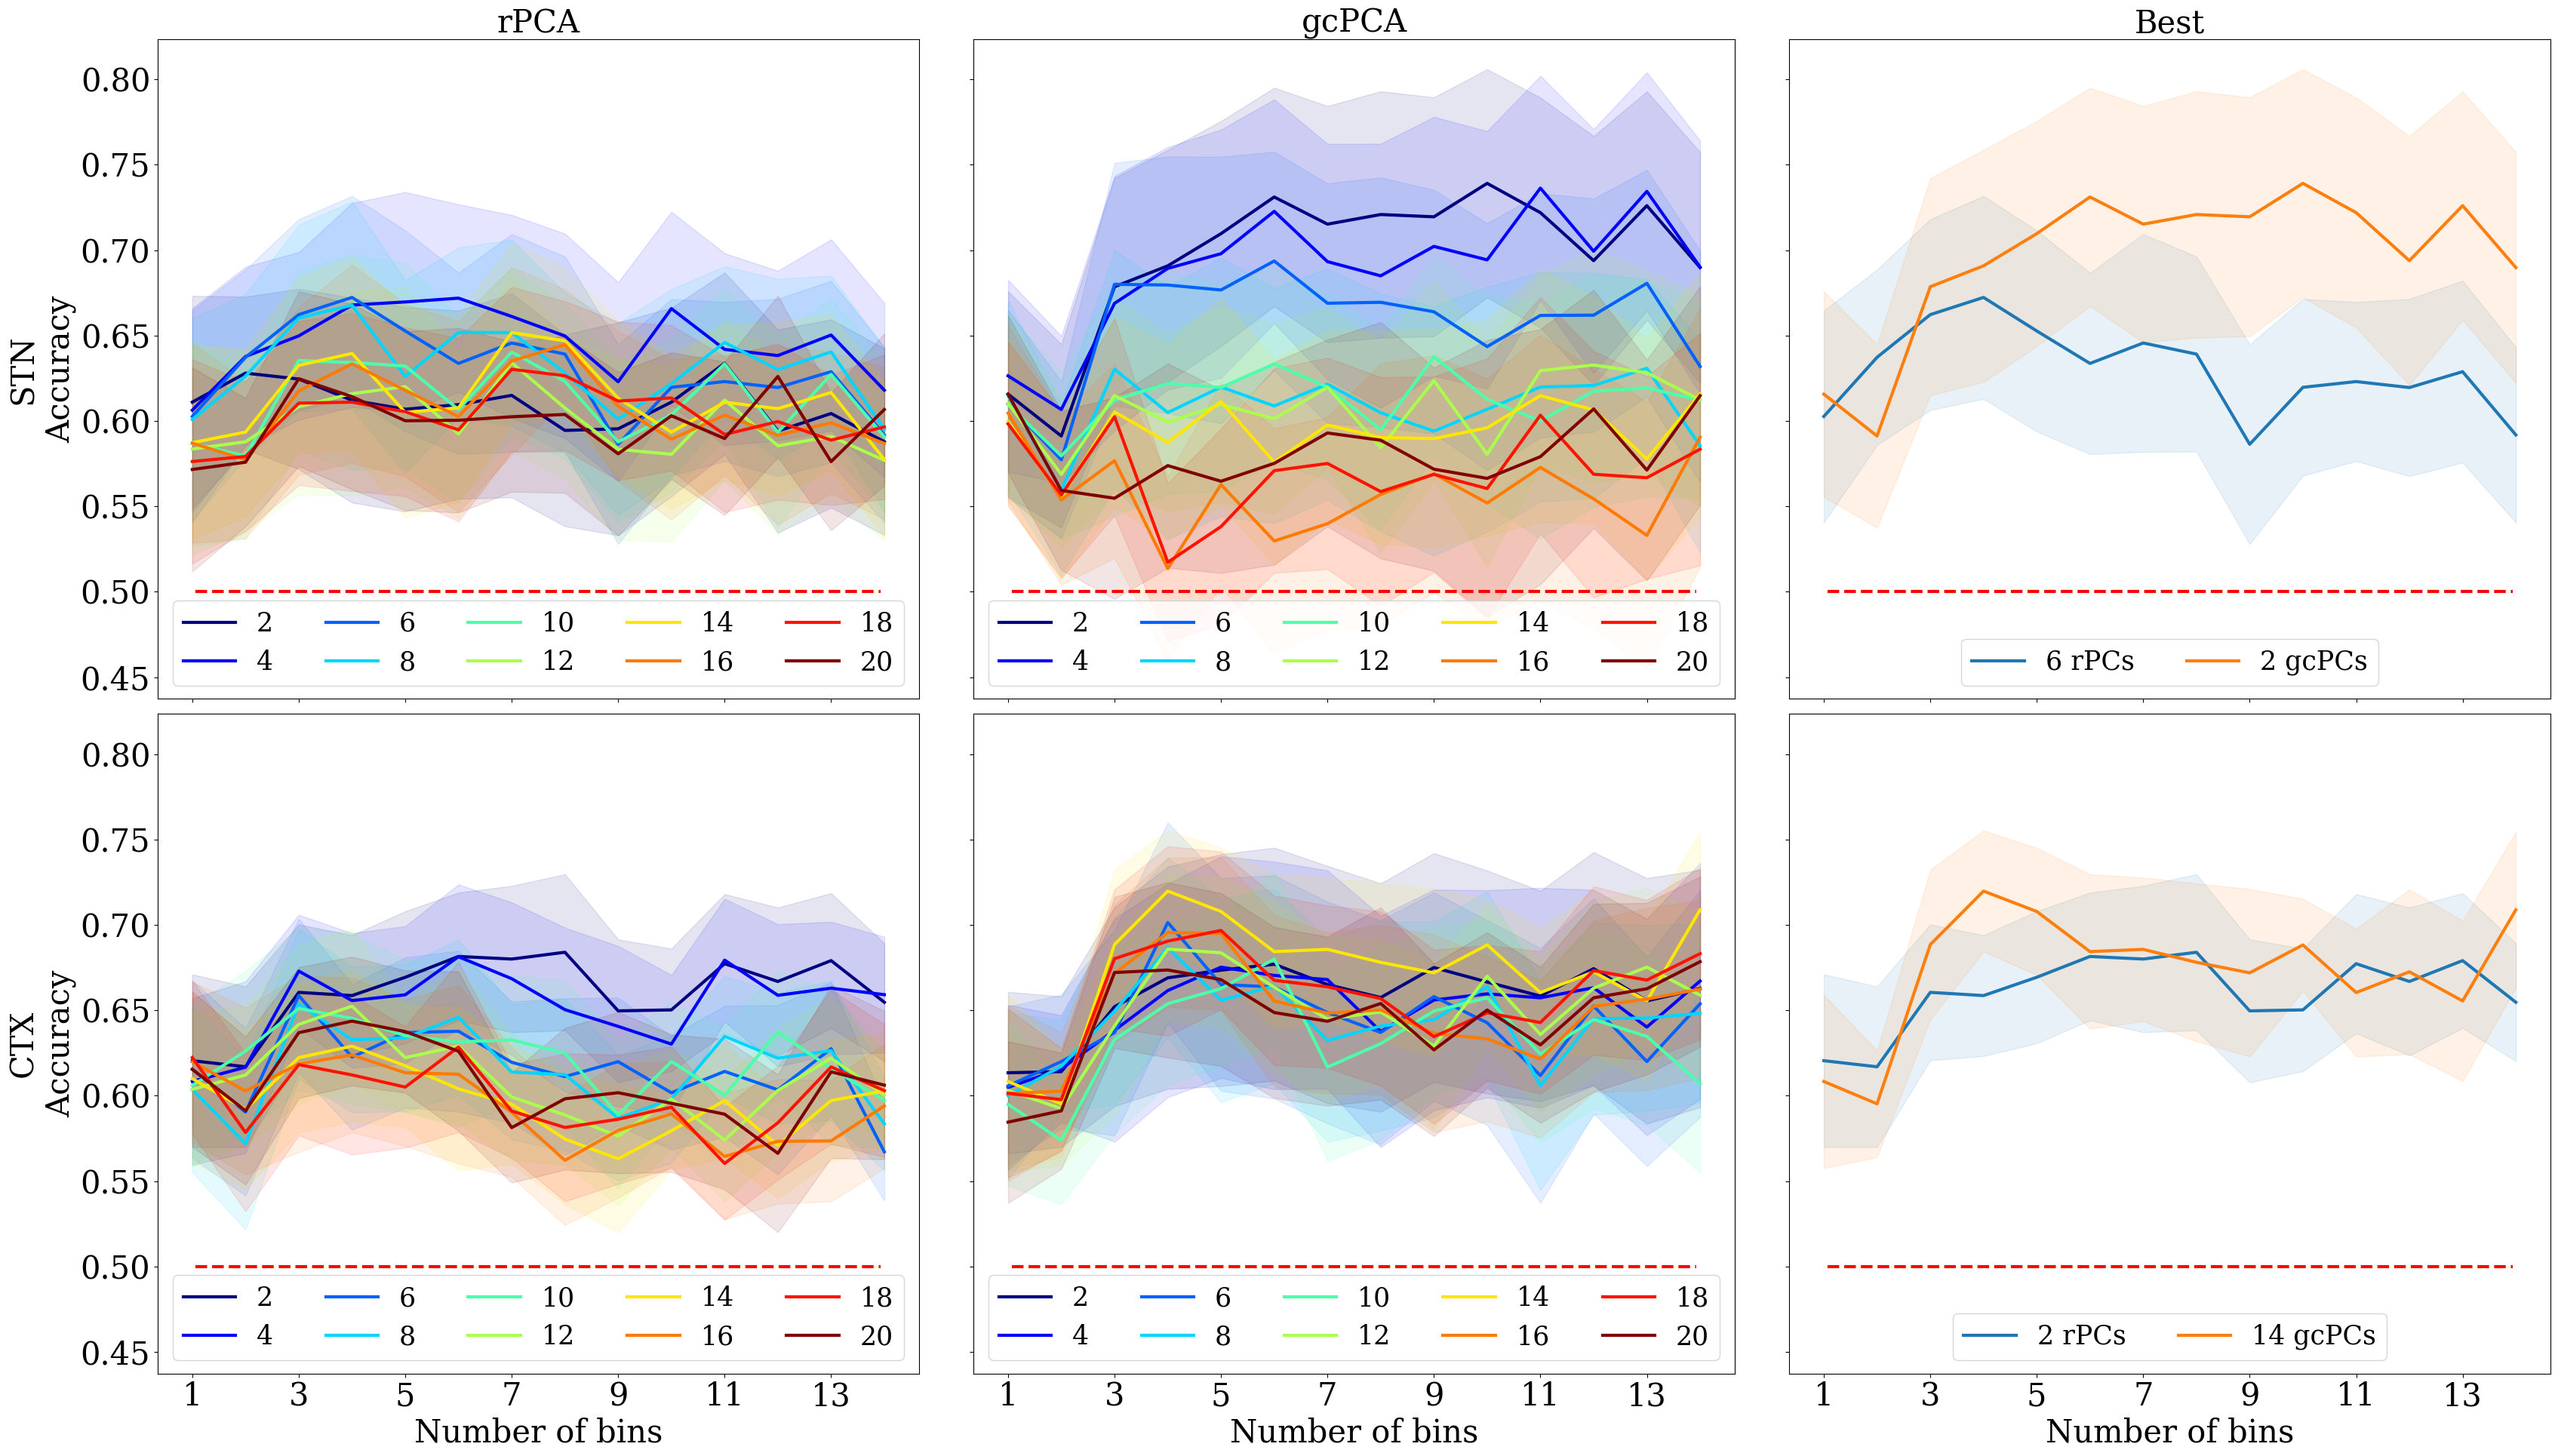

In [4]:
data_to_plot_files = glob.glob(op.join('./outputs-7/*PCA_outputs_*.npy'))  # ./outputs-3/
print(f"{len(data_to_plot_files)} file(s) to plot: {data_to_plot_files}")

all_n_PCs = sorted(list(set(get_file_number(file) for file in data_to_plot_files)))
colors_pool = plt.cm.jet(np.linspace(0, 1, len(all_n_PCs)))
n_PCs_to_color = dict(zip(all_n_PCs, colors_pool))

n_splits = 10
methods_configuration = {
    'rPCA': {'col': 0, 'label': 'rPCA'},
    'gcPCA': {'col': 1, 'label': 'gcPCA'}
}

best_gcPCA = {}

fig, axes = plt.subplots(2, 3, figsize=(40, 20), sharex=True, sharey=True, constrained_layout=True)
areas = ['stn', 'ctx']

for idx_row, area in enumerate(areas):
    best_file = {}  # store the best of each method to plot in the last column

    # Loop through the methods defined in the configuration
    for method_name, config in methods_configuration.items():
        # Filter files for the current method and area
        files = sorted([file for file in data_to_plot_files if method_name in file and area in file])

        if method_name == 'rPCA':
            files = [file for file in files if get_file_number(file) % 2 == 0]

        files.sort(key=get_file_number)  # Sort files based on the number of PCs

        # Plot each file for the current method and area
        for file in files:
            data = np.load(file, allow_pickle=True).item()
            n_PCs = get_file_number(file)

            plot_accuracy_curve(axes[idx_row, config['col']], data, file,
                                n_splits=n_splits, method_name=config['label'],
                                color=n_PCs_to_color[n_PCs],
                                alpha=0.1)

        # Get the best file for the current method and area
        best_data, best_file_name, n_best_bins = get_best_file_info(files)
        best_file[method_name] = (best_data, best_file_name)

    # Plot the best performing file for each method in the last column
    for method_name, (best_data, best_file_name) in best_file.items():
        print(f"Best file for {method_name} in {area}: {best_file_name}")
        if best_file_name is not None:
            n_PCs = get_file_number(best_file_name)
            plot_accuracy_curve(axes[idx_row, 2], best_data, best_file_name,
                                method_name=f"{method_name}",
                                linewidth=3, n_splits=n_splits, alpha=0.1,
                                meth_in_label=True)  # color=n_PCs_to_color[n_PCs],
        
        if 'gcPCA' in best_file_name:
            best_gcPCA[area] = (best_data, best_file_name)
            
    # Add the chance-level line and the legend
    for col_idx, ax in enumerate(axes[idx_row, :]):
        ax.axhline(0.5, xmin=0.05, xmax=0.95, color='red', linestyle='--', linewidth=3)
        ax.legend(loc='lower center',
                fontsize=25,
                ncols=5)
        ax.tick_params(axis='y', labelsize=30)

    axes[idx_row, 0].set_ylabel(f'{area.upper()}\nAccuracy', fontsize=30)

col_titles = ['rPCA', 'gcPCA', 'Best']
for i, title in enumerate(col_titles):
    axes[0, i].set_title(f"{title}", fontsize=30)

for ax in axes[1, :]:
    ax.set_xlabel('Number of bins', fontsize=30)
    ax.set_xticks(np.arange(len(best_data['accuracy']))[::2])
    ax.set_xticklabels([f'{int(x+1)}' for x in np.arange(len(best_data['accuracy']))[::2]], fontsize=30)

plt.tight_layout(rect=[0, 0, 0.85, 0.97])
# plt.savefig('./plots/GL_PCA-based_logit_accuracy.png', dpi=300)
# plt.savefig('./plots/GL_PCA-based_logit_accuracy.svg', format='svg')
plt.show()

## Plot the comparison between the best gcPCA models across brain regions

Best gcPCA file for stn: ./outputs-7\gcPCA_outputs_2_stn.npy with 2 gcPCs and max accuracy of 0.7391 +/- 0.2113 at bin 10/14
Best gcPCA file for stn: ./outputs-7\gcPCA_outputs_2_stn.npy with 2 gcPCs and mean accuracy of 0.6960 +/- 0.0416 
Best gcPCA file for ctx: ./outputs-7\gcPCA_outputs_14_ctx.npy with 14 gcPCs and max accuracy of 0.7198 +/- 0.1121 at bin 4/14
Best gcPCA file for ctx: ./outputs-7\gcPCA_outputs_14_ctx.npy with 14 gcPCs and mean accuracy of 0.6732 +/- 0.0340 


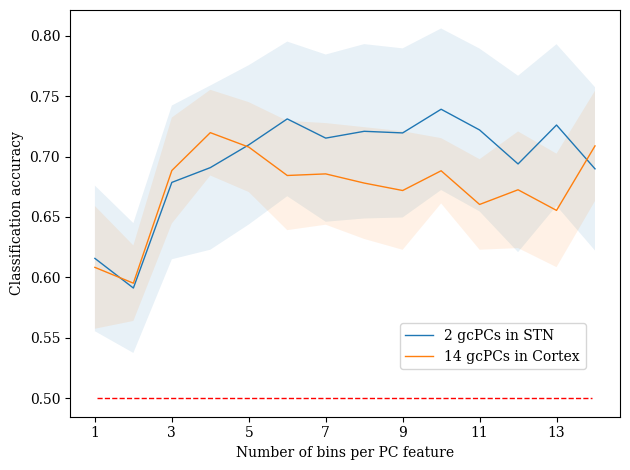

In [31]:
fontsize = 10

for i, (area, data) in enumerate(best_gcPCA.items()):
    accuracy = np.array(data[0]['accuracy'], dtype=float)
    sem = np.array(data[0]['variance'], dtype=float) / np.sqrt(float(n_splits))
    n_PCs = get_file_number(data[1])
    x_axis = np.arange(len(accuracy))

    upper, lower = accuracy + sem, accuracy - sem
    label = f"{n_PCs} gcPCs in {'STN' if area == "stn" else "Cortex"}"

    # Plot the main line
    line, = plt.plot(x_axis, accuracy,
                    label=label,
                    linewidth=1)
    
    var_at_best = data[0]['variance'][np.argmax(accuracy)]
    
    print(f"Best gcPCA file for {area}: {data[1]} with {n_PCs} gcPCs and max accuracy of {np.max(accuracy):.4f} +/- {var_at_best:.4f} at bin {np.argmax(accuracy)+1}/{len(accuracy)}")
    print(f"Best gcPCA file for {area}: {data[1]} with {n_PCs} gcPCs and mean accuracy of {np.mean(accuracy):.4f} +/- {np.std(accuracy):.4f} ")
    
    # Plot the shaded SEM area
    plt.fill_between(x_axis, lower, upper, alpha=0.1)

plt.axhline(0.5, xmin=0.05, xmax=0.95, color='red', linestyle='--', linewidth=1)
plt.xlabel('Number of bins per PC feature', fontsize=fontsize)
plt.xticks(x_axis[::2], labels=[f'{int(x+1)}' for x in x_axis[::2]], fontsize=fontsize)  # [::2]

plt.ylabel('Classification accuracy', fontsize=fontsize)
plt.tick_params(axis='y', labelsize=fontsize)
# plt.title('Logit classification accuracy as a function of the number of bins used for PC features')
plt.legend(loc='lower right', bbox_to_anchor=(0.95, 0.1), fontsize=fontsize)

plt.tight_layout()
# plt.savefig('./plots/GL_PCA-based_logit_accuracy_best.png', dpi=300)
# plt.savefig('./plots/GL_PCA-based_logit_accuracy_best.svg', format='svg')
plt.show()

## For the given best PCA models, plot their coefficients as a function of the number of bins

40 file(s) to plot: ['./outputs-7\\gcPCA_outputs_10_ctx.npy', './outputs-7\\gcPCA_outputs_10_stn.npy', './outputs-7\\gcPCA_outputs_12_ctx.npy', './outputs-7\\gcPCA_outputs_12_stn.npy', './outputs-7\\gcPCA_outputs_14_ctx.npy', './outputs-7\\gcPCA_outputs_14_stn.npy', './outputs-7\\gcPCA_outputs_16_ctx.npy', './outputs-7\\gcPCA_outputs_16_stn.npy', './outputs-7\\gcPCA_outputs_18_ctx.npy', './outputs-7\\gcPCA_outputs_18_stn.npy', './outputs-7\\gcPCA_outputs_20_ctx.npy', './outputs-7\\gcPCA_outputs_20_stn.npy', './outputs-7\\gcPCA_outputs_2_ctx.npy', './outputs-7\\gcPCA_outputs_2_stn.npy', './outputs-7\\gcPCA_outputs_4_ctx.npy', './outputs-7\\gcPCA_outputs_4_stn.npy', './outputs-7\\gcPCA_outputs_6_ctx.npy', './outputs-7\\gcPCA_outputs_6_stn.npy', './outputs-7\\gcPCA_outputs_8_ctx.npy', './outputs-7\\gcPCA_outputs_8_stn.npy', './outputs-7\\rPCA_outputs_10_ctx.npy', './outputs-7\\rPCA_outputs_10_stn.npy', './outputs-7\\rPCA_outputs_12_ctx.npy', './outputs-7\\rPCA_outputs_12_stn.npy', './outp

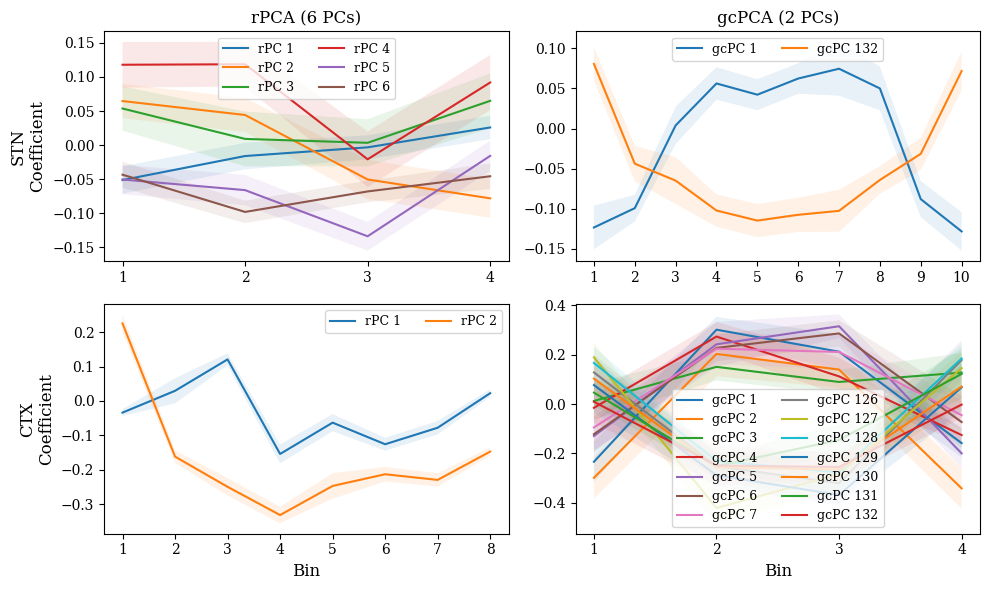

In [ ]:
data_to_plot_files = glob.glob(op.join('./outputs-7/*PCA_outputs_*.npy'))  # ./outputs-3/
print(f"{len(data_to_plot_files)} file(s) to plot: {data_to_plot_files}")

areas = ['stn', 'ctx']
bins = np.arange(1, 15)  # 14 bins
n_splits = 10
labels = []
total_gcPCs = np.arange(1, 133, 1)  # 1 to 132 (1-based gcPC indices)

methods_configuration = {
    'rPCA': {'col': 0, 'label': 'rPCA'},
    'gcPCA': {'col': 1, 'label': 'gcPCA'}
}

# Plot the coefficients: for each method and area, plot traces for each bin 
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=False, sharey=False)

for row, area in enumerate(areas):
    # Loop through the methods defined in the configuration
    for col, method_name in enumerate(methods_configuration.keys()):
        files = sorted([file for file in data_to_plot_files if method_name in file and area in file])
        files.sort(key=get_file_number)  # Sort files based on the number of PCs
        data, file, best_n_bins = get_best_file_info(files)

        # Store only the best PC's data
        methods_configuration[method_name][f'data_{area}'] = data
        methods_configuration[method_name][f'n_bins_{area}'] = best_n_bins
        methods_configuration[method_name][f'file_{area}'] = file

        ax = axes[row, col]

        coefs = data['mean_coefficients']
        var_coefs = data['var_coefficients']
        best_coefs = coefs[best_n_bins]
        best_var_coefs = var_coefs[best_n_bins]

        n_PCs = get_file_number(file)  # Get number of PCs for that best file.

        # Plot coefficients for each PC across the current file's bins
        step = best_n_bins + 1
        for PC_idx in range(n_PCs):
            y = best_coefs[PC_idx*step:(PC_idx+1)*step]
            x = np.arange(1, len(y) + 1)
            sem = best_var_coefs[PC_idx*step:(PC_idx+1)*step] / np.sqrt(n_splits)

            if 'gc' in method_name:
                half_n_PCs = int((n_PCs // 2))

                gcPCs_A = np.arange(0, half_n_PCs, 1)  # [0, 1, 2, ..., half_n_PCs-1]
                gcPCs_B = np.flip(np.arange(-1, -half_n_PCs - 1, -1))  # [-1, -2, -3, ..., -half_n_PCs]
                gcPCs_AB = np.concatenate([gcPCs_A, gcPCs_B])  # [0, 1, 2, ..., half_n_PCs-1, -half_n_PCs, ..., -3, -2, -1]
                # print(f"{area} | gcPCs_AB order for {n_PCs} gcPCs: {gcPCs_AB}")

                label = f'gcPC {total_gcPCs[gcPCs_AB[PC_idx]]}'
            else:
                label = f'rPC {PC_idx+1}'
            labels.append(label) if label not in labels else None

            ax.plot(x, y, label=label)
            ax.fill_between(x, np.asarray(y) - np.asarray(sem), np.asarray(y) + np.asarray(sem), alpha=0.1)

        ax.set_xticks(np.arange(1, step + 1))
        ax.set_xticklabels(np.arange(1, step + 1))
        ax.set_xlabel('Bin', fontsize=12) if row == 1 else None
        ax.set_ylabel(f'{area.upper()}\nCoefficient', fontsize=12) if col == 0 else None
        ax.legend(fontsize=9, loc='best', ncol=2)  # upper right
        ax.set_title(f'{method_name} ({n_PCs} PCs)') if row == 0 else None

# fig.suptitle("Relevant bins for logit")
plt.tight_layout()
# plt.savefig('./plots/GL_PCA-based_logit_coefs.png', dpi=300)
# plt.savefig('./plots/GL_PCA-based_logit_coefs.svg', format='svg')
plt.show()

### Save the 4 best argmax for each of the best models across regions (all PCs coufounded) based on their maximum absolute coefficients 

In [24]:
plot_top4_abs_argmax = {}

for area in areas:
    for method_name in methods_configuration:
        data = methods_configuration[method_name].get(f"data_{area}")
        best_n_bins = methods_configuration[method_name].get(f"n_bins_{area}")
        file_name = methods_configuration[method_name].get(f"file_{area}")

        coefs = data['mean_coefficients']
        var_coefs = data['var_coefficients']
        best_coefs = coefs[best_n_bins]
        best_var_coefs = var_coefs[best_n_bins]
        
        n_PCs = get_file_number(file_name)
        step = int(best_n_bins) + 1

        y = best_coefs.reshape(n_PCs, step)
        var_y = best_var_coefs.reshape(n_PCs, step)
        abs_y = np.abs(y)        
        top_indices = np.argsort(abs_y.ravel())[::-1][:4]

        selections = []
        for flat_idx in top_indices:
            pc_idx, bin_idx = divmod(int(flat_idx), step)
            selections.append({
                'method': method_name,
                'area': area,
                'pc_number': int(pc_idx + 1),
                'bin_number': int(bin_idx + 1),
                'coef': float(y[pc_idx, bin_idx]),
                'coef_variance': float(var_y[pc_idx, bin_idx]),
            })

        plot_top4_abs_argmax[f"{method_name}_{area}"] = {
            'file': file_name,
            'best_n_bins': int(best_n_bins + 1),
            'n_PCs': n_PCs,
            'top4': selections,
        }

plot_top4_abs_argmax
np.save('./outputs-7/waveforms_to_look_at.npy', plot_top4_abs_argmax)

## Plot TF features-based logits across brain regions

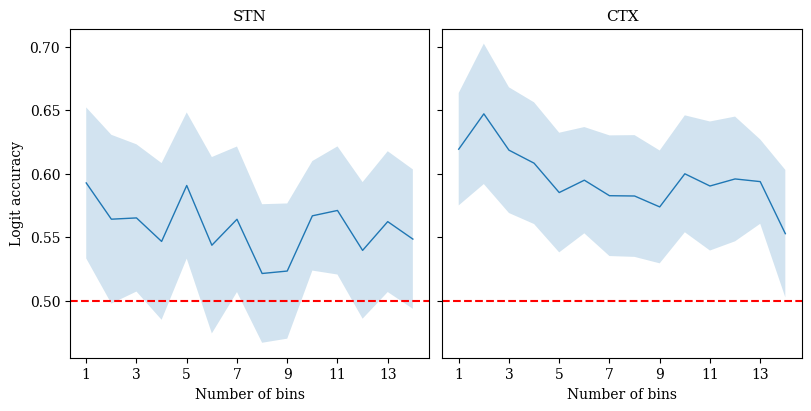

In [16]:
areas = ['stn', 'ctx']

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True, constrained_layout=True)

for col_idx, area in enumerate(areas):
    ax = axes[col_idx]
    tf_data = np.load(f'./Group-Level_outputs/outputs-8/tf_outputs_{area}.npy', allow_pickle=True).item()

    n_bins = tf_data['Metdata']['n_bins']
    n_bins_count = len(n_bins)
    accuracy = np.array(tf_data['accuracy'], dtype=float)
    variance = np.array(tf_data['variance'], dtype=float)

    mean = accuracy[:14]
    sem = variance[:14] / np.sqrt(10)

    ax.plot(n_bins, mean, lw=1,)
    ax.fill_between(n_bins, mean - sem, mean + sem, alpha = 0.2)

    ax.axhline(0.5, color='red', linestyle='--')
    ax.set_xlabel('Number of bins', fontsize=10)
    ax.set_title(f'{area.upper()}', fontsize=11)
    ax.set_xticks(n_bins[::2])

axes[0].set_ylabel('Logit accuracy', fontsize=10)

plt.show()